# 261: combiner A, the intersection of a fixed panel of alphabet-ksize pairs

Input: the table [notebook 260](260_kmerseek_region_table.ipynb) writes, one row per human
query, target species, merged region and alphabet-ksize pair (one reduced amino-acid
alphabet at one k-mer size; the column is `arm`). A merged region is the stretch of the
query that overlapping kmerseek calls cover, joined across every pair.

Combiner A calls a merged region when every pair in a fixed panel of n pairs calls it at
`region_evalue` < E_max. A region one pair in the panel misses is not called. So the
intersection can only lose regions as n grows; the question is how many of the lost
regions were false calls.

`region_evalue` is kmerseek's Karlin-Altschul E-value: how many regions scoring at least
this well a search of the same database would find by chance. It is not calibrated across
alphabets (in the proteome-wide run of notebook 241, 81 of 152 pairs had no E-value fit),
so the count of calls on shuffled queries is the false-call estimate used alongside it. A
shuffled query is the human protein with its residues shuffled in pairs (dipeptides); it
has no true homolog, so every region called on it is false.

**Truth.** A merged region is a true call when at least half of it lies inside one feature
of the truth set (landed fraction = overlap / region length >= 0.5). Two truth sets:
Swiss-Prot features (DOMAIN, REGION, TRANSMEM, REPEAT, BINDING and the rest, the key
notebook 231 scored on) and Pfam domains.

- Precision = true calls / calls, over calls on queries that have at least one feature in
  that truth set. Higher is fewer false calls.
- Recall = truth features with at least one called region landed inside them / all truth
  features on the split's queries, counted once per target species searched. Higher is
  more features found.

**Procedure, fixed before running.**
1. Tune split only. For each E_max in {0.1, 1, 10}: start from the single pair with the
   highest Swiss-Prot precision, add the pair that raises it most, and stop at the first
   step that does not raise it (ties go to the panel that calls more regions). The panel
   has at least two pairs, since one pair alone is not an intersection. The path is drawn
   out to five pairs either way.
2. Of the three stopping panels, freeze the one with the highest tune precision (ties to
   more calls, then the smaller E_max) and save it to `261_intersection_panel.yaml`.
3. Report the frozen panel on the test split. No choice is made on test.
4. For test queries with two or more Pfam domains, count the domains each method lands in:
   the frozen panel, the panel's first pair alone (the single pair with the highest tune
   precision), and phmmer.

The split is by query: `tune` or `test` by the first byte of SHA-1 of the accession
(notebook 260). A shuffled query goes to its source protein's half.

## Which data this execution reads

The kmerseek 0.4 midi-plus run with extension (`make run-midi-plus-0.4-extend`, PR #88)
and its shuffled-query twin (`M04_RUN=decoy`) have not run. As of 1 Oct 2026 the run
directory on Sherlock holds the same five region files notebook 260 read. So the table has
four pairs, all one alphabet at one k: hp_pbotc_1st_ed2 at k=19 against zebrafish, at
extension penalties 1.63 and 2, each searched with the built-in alphabet and with the same
two-letter partition given as already-encoded sequences (`encoded_`). The fly protein20
k=7 file has no E-values and contributes nothing.

What that means for this execution:
- The panel can have at most four pairs, and the four are near-copies of one search.
  Agreement between them is not independent evidence.
- There is no shuffled-query table, so the decoy column is empty and no false-call count
  from shuffled queries exists yet.
- Every number is zebrafish only.

The code reads whatever `region_table.parquet` and `region_table_decoy.parquet` hold, so
the notebook reruns unchanged once the full run is reduced by notebook 260.

phmmer (HMMER3 single-sequence search) comes from the midi-plus region benchmark run
(1-2 Sept 2026): the same 998 human queries against the zebrafish proteome, per-domain
hits with their i-Evalue, query span 1-based inclusive.

In [1]:
import hashlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

sys.path.insert(0, str(Path.cwd()))
import mhc_region_utils as mu
import region_combiner_261 as rc
import region_table_260 as rt

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

BASE = Path.home() / "data" / "qfo-pfam-region-midi-plus-0.4" / "260_region_table"
TABLE = BASE / "region_table.parquet"
TRUTH_PAIRS = BASE / "region_table_truth_pairs.parquet"
DECOY_TABLE = BASE / "region_table_decoy.parquet"
PFAM_TRUTH = mu.MIDI_DIR / "truth" / "human_domain_truth.parquet"
SWISSPROT_TRUTH = mu.MIDI_DIR / "truth_swissprot" / "human_swissprot_truth.parquet"
PHMMER_DIR = mu.MIDI_DIR / "regions" / "hmmer3_phmmer"
PANEL_YAML = Path.cwd() / "261_intersection_panel.yaml"
FIG = Path.cwd().parent / "figures"

table = pl.read_parquet(TABLE)
truth_pairs = pl.read_parquet(TRUTH_PAIRS)
truth = rt.load_truth(PFAM_TRUTH, SWISSPROT_TRUTH)
decoy_table = pl.read_parquet(DECOY_TABLE) if DECOY_TABLE.exists() else None

def sha256(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()

print(f"{TABLE}: {table.height:_} rows, sha256 {sha256(TABLE)[:16]}")
print(f"shuffled-query table: {'present' if decoy_table is not None else 'absent, ' + str(DECOY_TABLE)}")
summary = pl.read_parquet(BASE / "reduced" / "reduce_summary.parquet")
print(summary.select("species", "arm", "n_regions", "n_kept", "has_evalue", "extension_fit_refused")
      .sort("species", "arm"))
regions = table.unique(subset=rc.KEY)
print(table.group_by("species", "arm").agg(rows=pl.len(), queries=pl.col("accession").n_unique())
      .sort("species", "arm"))
print("merged regions by split:", regions.group_by("split").len().sort("split").to_dicts())
print("queries by split:", table.unique("accession").group_by("split").len().sort("split").to_dicts())

/Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet: 6_140 rows, sha256 c936f3884dbbb25f
shuffled-query table: absent, /Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table_decoy.parquet
shape: (5, 6)
┌───────────┬──────────────────────────────────────┬───────────┬────────┬────────────┬───────────────────────┐
│ species   ┆ arm                                  ┆ n_regions ┆ n_kept ┆ has_evalue ┆ extension_fit_refused │
│ ---       ┆ ---                                  ┆ ---       ┆ ---    ┆ ---        ┆ ---                   │
│ str       ┆ str                                  ┆ i64       ┆ i64    ┆ bool       ┆ null                  │
╞═══════════╪══════════════════════════════════════╪═══════════╪════════╪════════════╪═══════════════════════╡
│ fly       ┆ protein20_k7                         ┆ 154066    ┆ 0      ┆ false      ┆ null                  │
│ zebrafish ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ 10611511  ┆ 65418  ┆ tru

## Greedy search on the tune split

One row per step of the search, for each E_max. `n_called` is merged regions the panel
calls on tune queries; `n_decoy_called` is the same panel's calls on the shuffled tune
queries (empty until that run exists). `improved` says whether the step raised Swiss-Prot
precision; `is_stop` marks the panel the search stops at.

In [2]:
tune = rc.Scorer(table, truth_pairs, truth, "tune", decoy_table)
print(f"pairs available: {len(tune.arms)}: {tune.arms}")
print(f"target species: {tune.species}")
print(f"tune truth features (x {len(tune.species)} species): "
      f"Swiss-Prot {tune.n_features['swissprot']:_}, Pfam {tune.n_features['pfam']:_}")
paths = pl.concat([rc.greedy(tune, e) for e in rc.EMAX_GRID], how="diagonal_relaxed")
SHOW = ["emax", "n_arms", "added_arm", "n_called", "n_decoy_called",
        "precision_swissprot", "recall_swissprot", "precision_pfam", "recall_pfam",
        "improved", "is_stop"]
print(paths.select(SHOW))
frozen = rc.freeze(paths)
PANEL = frozen["panel"].split(" + ")
EMAX = frozen["emax"]
SINGLE = PANEL[0]
print(f"\nfrozen panel ({len(PANEL)} pairs, E_max {EMAX:g}):")
for a in PANEL:
    print("  ", a)
print(f"its first pair alone (highest tune Swiss-Prot precision at E_max {EMAX:g}): {SINGLE}")

pairs available: 4: ['encoded_hp_pbotc_1st_ed2_k19_ext1.63', 'encoded_hp_pbotc_1st_ed2_k19_ext2', 'hp_pbotc_1st_ed2_k19_ext1.63', 'hp_pbotc_1st_ed2_k19_ext2']
target species: ['zebrafish']
tune truth features (x 1 species): Swiss-Prot 3_505, Pfam 1_250
shape: (12, 11)
┌──────┬────────┬──────────────────────────────────────┬──────────┬────────────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬──────────┬─────────┐
│ emax ┆ n_arms ┆ added_arm                            ┆ n_called ┆ n_decoy_called ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ improved ┆ is_stop │
│ ---  ┆ ---    ┆ ---                                  ┆ ---      ┆ ---            ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---      ┆ ---     │
│ f64  ┆ i64    ┆ str                                  ┆ i64      ┆ null           ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ bool     ┆ bool    │
╞══════╪════════╪══

## Precision and recall as pairs are added

One line per truth set for the frozen E_max: each point is the panel after n pairs, so
reading left to right along the line is adding pairs. The ringed point is the frozen
panel. Recall can only fall as n grows; precision can move either way.

shape: (4, 8)
┌────────┬──────────────────────────────────────┬──────────┬─────────────────────┬──────────────────┬────────────────┬─────────────┬─────────┐
│ n_arms ┆ added_arm                            ┆ n_called ┆ precision_swissprot ┆ recall_swissprot ┆ precision_pfam ┆ recall_pfam ┆ is_stop │
│ ---    ┆ ---                                  ┆ ---      ┆ ---                 ┆ ---              ┆ ---            ┆ ---         ┆ ---     │
│ i64    ┆ str                                  ┆ i64      ┆ f64                 ┆ f64              ┆ f64            ┆ f64         ┆ bool    │
╞════════╪══════════════════════════════════════╪══════════╪═════════════════════╪══════════════════╪════════════════╪═════════════╪═════════╡
│ 1      ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ 824      ┆ 0.397959            ┆ 0.092725         ┆ 0.557039       ┆ 0.3248      ┆ false   │
│ 2      ┆ encoded_hp_pbotc_1st_ed2_k19_ext2    ┆ 780      ┆ 0.384615            ┆ 0.085592         ┆ 0.561538       ┆ 0.3112   

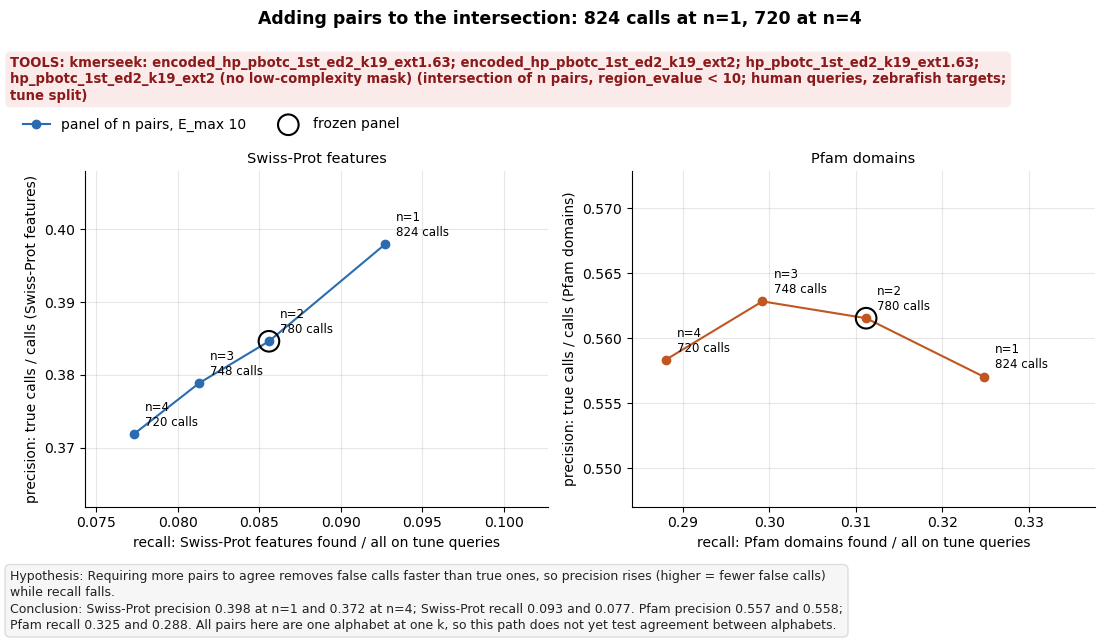

In [3]:
path = paths.filter(pl.col("emax") == EMAX).sort("n_arms")
print(path.select("n_arms", "added_arm", "n_called", "precision_swissprot", "recall_swissprot",
                  "precision_pfam", "recall_pfam", "is_stop"))

SP_C, PF_C = "#2B6CB0", "#C05621"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, ts, name, color in ((axes[0], "swissprot", "Swiss-Prot features", SP_C),
                            (axes[1], "pfam", "Pfam domains", PF_C)):
    x, y = path[f"recall_{ts}"].to_numpy(), path[f"precision_{ts}"].to_numpy()
    ax.plot(x, y, color=color, lw=1.5, marker="o", ms=6, label=f"panel of n pairs, E_max {EMAX:g}")
    stop = path["is_stop"].to_numpy()
    ax.scatter(x[stop], y[stop], s=220, facecolors="none", edgecolors="black", lw=1.5,
               label="frozen panel", zorder=3)
    for n, xi, yi, nc in zip(path["n_arms"], x, y, path["n_called"]):
        ax.annotate(f"n={n}\n{nc:_} calls", (xi, yi), xytext=(8, 6), textcoords="offset points",
                    fontsize=8.5)
    ax.set_xlabel(f"recall: {name} found / all on tune queries")
    ax.set_ylabel(f"precision: true calls / calls ({name})")
    pad_x = max((x.max() - x.min()) * 0.35, 0.01)
    pad_y = max((y.max() - y.min()) * 0.35, 0.01)
    ax.set_xlim(x.min() - pad_x * 0.3, x.max() + pad_x)
    ax.set_ylim(y.min() - pad_y, y.max() + pad_y)
    ax.set_title(name, fontsize=10.5)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.93))
first, last = path.row(0, named=True), path.row(-1, named=True)
mu.finish_figure(
    fig, FIG / "261_intersection_precision_recall_by_n_zebrafish_tune.png",
    tools=mu.tools_text(kmerseek=tune.arms, lc=False,
                        note=f"intersection of n pairs, region_evalue < {EMAX:g}; human queries, zebrafish targets; tune split"),
    title=f"Adding pairs to the intersection: {first['n_called']:_} calls at n=1, {last['n_called']:_} at n={last['n_arms']}",
    hypothesis="Requiring more pairs to agree removes false calls faster than true ones, so "
               "precision rises (higher = fewer false calls) while recall falls.",
    conclusion=(f"Swiss-Prot precision {first['precision_swissprot']:.3f} at n=1 and "
                f"{last['precision_swissprot']:.3f} at n={last['n_arms']}; Swiss-Prot recall "
                f"{first['recall_swissprot']:.3f} and {last['recall_swissprot']:.3f}. Pfam precision "
                f"{first['precision_pfam']:.3f} and {last['precision_pfam']:.3f}; Pfam recall "
                f"{first['recall_pfam']:.3f} and {last['recall_pfam']:.3f}. All pairs here are one "
                "alphabet at one k, so this path does not yet test agreement between alphabets."),
    layout=False,
)

## Calls on real and shuffled queries for each panel

For every panel the search visited on tune, the number of merged regions it calls on real
queries and on shuffled queries. A shuffled query has no homolog, so its calls estimate
how many of the real calls are false at the same panel and E_max.

shape: (12, 5)
┌──────┬────────┬───────────────────────────────────────────────────────────────────────────────────┬──────────┬────────────────┐
│ emax ┆ n_arms ┆ panel                                                                             ┆ n_called ┆ n_decoy_called │
│ ---  ┆ ---    ┆ ---                                                                               ┆ ---      ┆ ---            │
│ f64  ┆ i64    ┆ str                                                                               ┆ i64      ┆ null           │
╞══════╪════════╪═══════════════════════════════════════════════════════════════════════════════════╪══════════╪════════════════╡
│ 0.1  ┆ 1      ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63                                              ┆ 543      ┆ null           │
│ 0.1  ┆ 2      ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 + encoded_hp_pbotc_1st_ed2_k19_ext2          ┆ 540      ┆ null           │
│ 0.1  ┆ 3      ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 + encoded_hp_pbotc_1

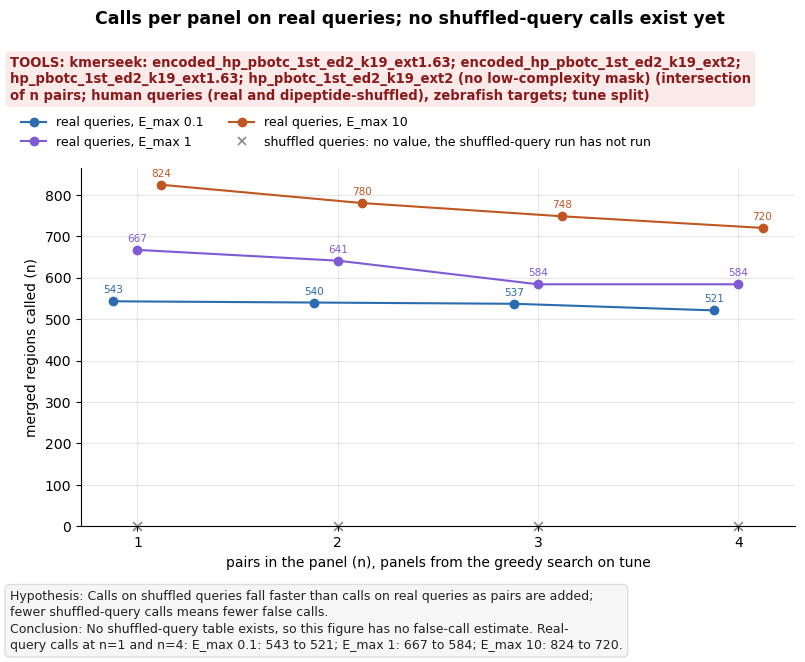

In [4]:
print(paths.select("emax", "n_arms", "panel", "n_called", "n_decoy_called"))
EMAX_COLORS = {0.1: "#2B6CB0", 1.0: "#805AD5", 10.0: "#C05621"}
MISSING = dict(marker="x", color="#888888", s=40, lw=1.2)
fig, ax = plt.subplots(figsize=(8, 4.8))
handles = []
for e in rc.EMAX_GRID:
    p = paths.filter(pl.col("emax") == e).sort("n_arms")
    off = {0.1: -0.12, 1.0: 0.0, 10.0: 0.12}[e]
    ax.plot(p["n_arms"] + off, p["n_called"], color=EMAX_COLORS[e], marker="o", lw=1.5)
    if p["n_decoy_called"].null_count() < p.height:
        d = p.filter(pl.col("n_decoy_called").is_not_null())
        ax.plot(d["n_arms"] + off, d["n_decoy_called"], color=EMAX_COLORS[e], marker="s",
                lw=1.5, ls="--", mfc="white")
    for n, v in zip(p["n_arms"], p["n_called"]):
        ax.annotate(f"{v:_}", (n + off, v), xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=7.5, color=EMAX_COLORS[e])
no_decoy = paths["n_decoy_called"].null_count() == paths.height
if no_decoy:
    ax.scatter(paths["n_arms"].unique().sort(), np.zeros(paths["n_arms"].n_unique()), clip_on=False, **MISSING)
from matplotlib.lines import Line2D
handles = [Line2D([], [], color=EMAX_COLORS[e], lw=1.5, marker="o") for e in rc.EMAX_GRID]
labels = [f"real queries, E_max {e:g}" for e in rc.EMAX_GRID]
if no_decoy:
    handles.append(Line2D([], [], ls="none", marker="x", color=MISSING["color"], mew=1.2))
    labels.append("shuffled queries: no value, the shuffled-query run has not run")
else:
    handles += [Line2D([], [], color="black", ls="--", marker="s", mfc="white")]
    labels += ["shuffled queries (same colour = same E_max)"]
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)
ax.set_xticks(sorted(paths["n_arms"].unique().to_list()))
ax.set_xlabel("pairs in the panel (n), panels from the greedy search on tune")
ax.set_ylabel("merged regions called (n)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(rect=(0, 0, 1, 0.9))
mu.finish_figure(
    fig, FIG / "261_intersection_real_vs_shuffled_calls_zebrafish_tune.png",
    tools=mu.tools_text(kmerseek=tune.arms, lc=False,
                        note="intersection of n pairs; human queries (real and dipeptide-shuffled), zebrafish targets; tune split"),
    title=("Calls per panel on real queries; no shuffled-query calls exist yet" if no_decoy
           else "Calls per panel on real and shuffled queries"),
    hypothesis="Calls on shuffled queries fall faster than calls on real queries as pairs are "
               "added; fewer shuffled-query calls means fewer false calls.",
    conclusion=("No shuffled-query table exists, so this figure has no false-call estimate. "
                f"Real-query calls at n=1 and n={paths['n_arms'].max()}: "
                + "; ".join(f"E_max {e:g}: {paths.filter((pl.col('emax') == e) & (pl.col('n_arms') == 1))['n_called'][0]:_} "
                            f"to {paths.filter(pl.col('emax') == e).sort('n_arms')['n_called'][-1]:_}"
                            for e in rc.EMAX_GRID) + "."
                if no_decoy else
                "; ".join(f"E_max {e:g}, n={r['n_arms']}: {r['n_called']:_} real, {r['n_decoy_called']:_} shuffled"
                          for e in rc.EMAX_GRID for r in paths.filter((pl.col('emax') == e) & pl.col('is_stop')).to_dicts())),
    layout=False,
)

## The frozen panel on the test split

The same numbers for the frozen panel on test queries, with its first pair alone at the
same E_max beside it. Nothing here was chosen on test.

In [5]:
test = rc.Scorer(table, truth_pairs, truth, "test", decoy_table)
rows = [dict(tune.score(PANEL, EMAX), method=f"intersection, n={len(PANEL)}"),
        dict(tune.score([SINGLE], EMAX), method="first pair alone"),
        dict(test.score(PANEL, EMAX), method=f"intersection, n={len(PANEL)}"),
        dict(test.score([SINGLE], EMAX), method="first pair alone")]
report = pl.DataFrame(rows, infer_schema_length=None).select(
    "split", "method", "emax", "n_called", "n_decoy_called",
    "n_called_on_swissprot_queries", "precision_swissprot", "n_found_swissprot", "recall_swissprot",
    "n_called_on_pfam_queries", "precision_pfam", "n_found_pfam", "recall_pfam")
print(f"test truth features (x {len(test.species)} species): "
      f"Swiss-Prot {test.n_features['swissprot']:_}, Pfam {test.n_features['pfam']:_}")
print(report)
print("\nfrozen panel, by name:")
for a in PANEL:
    print(f"  {a}")

test truth features (x 1 species): Swiss-Prot 3_677, Pfam 1_185
shape: (4, 13)
┌───────┬───────────────────┬──────┬──────────┬────────────────┬───────────────────────────────┬─────────────────────┬───────────────────┬──────────────────┬──────────────────────────┬────────────────┬──────────────┬─────────────┐
│ split ┆ method            ┆ emax ┆ n_called ┆ n_decoy_called ┆ n_called_on_swissprot_queries ┆ precision_swissprot ┆ n_found_swissprot ┆ recall_swissprot ┆ n_called_on_pfam_queries ┆ precision_pfam ┆ n_found_pfam ┆ recall_pfam │
│ ---   ┆ ---               ┆ ---  ┆ ---      ┆ ---            ┆ ---                           ┆ ---                 ┆ ---               ┆ ---              ┆ ---                      ┆ ---            ┆ ---          ┆ ---         │
│ str   ┆ str               ┆ f64  ┆ i64      ┆ null           ┆ i64                           ┆ f64                 ┆ i64               ┆ f64              ┆ i64                      ┆ f64            ┆ i64          ┆ f64        

## Saving the frozen panel

`261_intersection_panel.yaml` holds the panel's pairs, E_max, the rule that chose it and
its tune and test numbers, with the input table's checksum, so the comparison notebook can
reread it and check it reads the same table.

In [6]:
def clean(d: dict) -> dict:
    return {k: (None if isinstance(v, float) and v != v else v) for k, v in d.items()}

record = {
    "combiner": "A, intersection: a merged region is called when every pair in the panel "
                "calls it at region_evalue < emax",
    "panel": PANEL,
    "emax": EMAX,
    "single_pair": SINGLE,
    "selection": "greedy forward selection on the tune split from the single pair with the "
                 "highest Swiss-Prot precision (landed >= 0.5); stop at the first step that "
                 "does not raise it, at least 2 pairs; emax from {0.1, 1, 10} by the highest "
                 "tune precision at the stop",
    "tune": clean({k: v for k, v in report.row(0, named=True).items() if k not in ("split", "method")}),
    "test": clean({k: v for k, v in report.row(2, named=True).items() if k not in ("split", "method")}),
    "input_table": str(TABLE),
    "input_table_sha256": sha256(TABLE),
    "input_note": (f"{len(tune.arms)} pairs, species {tune.species}; shuffled-query table "
                   f"{'present' if decoy_table is not None else 'absent'}"),
    "notebook": "notebooks/261_combiner_a_intersection_panel.ipynb",
    "written": date.today().isoformat(),
}
PANEL_YAML.write_text(yaml.safe_dump(record, sort_keys=False, width=100))
print(PANEL_YAML.read_text())

combiner: 'A, intersection: a merged region is called when every pair in the panel calls it at region_evalue
  < emax'
panel:
- encoded_hp_pbotc_1st_ed2_k19_ext1.63
- encoded_hp_pbotc_1st_ed2_k19_ext2
emax: 10.0
single_pair: encoded_hp_pbotc_1st_ed2_k19_ext1.63
selection: greedy forward selection on the tune split from the single pair with the highest Swiss-Prot
  precision (landed >= 0.5); stop at the first step that does not raise it, at least 2 pairs; emax from
  {0.1, 1, 10} by the highest tune precision at the stop
tune:
  emax: 10.0
  n_called: 780
  n_decoy_called: null
  n_called_on_swissprot_queries: 741
  precision_swissprot: 0.38461538461538464
  n_found_swissprot: 300
  recall_swissprot: 0.08559201141226819
  n_called_on_pfam_queries: 780
  precision_pfam: 0.5615384615384615
  n_found_pfam: 389
  recall_pfam: 0.3112
test:
  emax: 10.0
  n_called: 720
  n_decoy_called: null
  n_called_on_swissprot_queries: 689
  precision_swissprot: 0.34107402031930334
  n_found_swissprot: 2

## Multi-domain queries: how many domains each method lands

For test queries with at least two Pfam domains, the number of those domains each method
lands in, per query and target species. A domain is landed when at least half of one call
lies inside it (the same landed >= 0.5 rule).

- Intersection: the frozen panel's called merged regions.
- First pair alone: merged regions that pair calls at the same E_max.
- phmmer: each per-domain hit's query span, at i-Evalue < the same E_max.

The two kmerseek rows use merged-region extents, which grow when calls chain across
domain borders (notebook 260, the plasminogen example); phmmer's hits are not merged. A
merged region that spans two domains lands in neither.

In [7]:
pf_dom = (truth.filter(pl.col("truth_set") == "pfam")
          .unique(subset=rc.FEATURE_KEY)
          .with_columns(split=rt.query_split(pl.col("accession"))))
multi = (pf_dom.filter(pl.col("split") == "test").group_by("accession").agg(n_domains=pl.len())
         .filter(pl.col("n_domains") >= 2))
grid = multi.join(pl.DataFrame({"species": test.species}), how="cross")
print(f"test queries with >= 2 Pfam domains: {multi.height}; domains on them: {multi['n_domains'].sum():_}")
print("domains per query:", multi.group_by("n_domains").len().sort("n_domains").to_dicts())

def merged_spans(rids: np.ndarray) -> pl.DataFrame:
    return test.regions.filter(pl.col("rid").is_in(rids)).join(
        test.t.unique(subset=rc.KEY).select(rc.KEY + ["merged_start", "merged_end"]), on=rc.KEY
    ).select("accession", "species", start="merged_start", end="merged_end")

phm = pl.concat([rc.load_phmmer(PHMMER_DIR / f"human_vs_{sp}.hmmer3_phmmer.tsv.gz", sp)
                 for sp in test.species])
phm = phm.filter(pl.col("evalue") < EMAX).select("accession", "species", start="qstart", end="qend")
spans = {
    f"intersection, n={len(PANEL)}": merged_spans(test.called(PANEL, EMAX)),
    "first pair alone": merged_spans(test.called([SINGLE], EMAX)),
    "phmmer": phm,
}
dom_in = pf_dom.filter(pl.col("accession").is_in(multi["accession"].implode()))
counts = grid
for name, s in spans.items():
    c = rc.domains_landed(s.filter(pl.col("accession").is_in(multi["accession"].implode())),
                          dom_in, "start", "end")
    counts = counts.join(c.rename({"n_landed": name}), on=["accession", "species"], how="left")
counts = counts.with_columns(pl.col(n).fill_null(0) for n in spans)
METHODS = list(spans)
dist = (counts.unpivot(index=["accession", "species", "n_domains"], on=METHODS,
                       variable_name="method", value_name="n_landed")
        .group_by("method", "n_landed").len("n_queries").sort("method", "n_landed"))
print(dist.pivot(on="method", index="n_landed", values="n_queries").fill_null(0).sort("n_landed"))
stats = counts.select(
    *[pl.col(n).mean().alias(f"mean | {n}") for n in METHODS],
    *[pl.col(n).median().alias(f"median | {n}") for n in METHODS],
    *[(pl.col(n) / pl.col("n_domains")).mean().alias(f"mean fraction | {n}") for n in METHODS],
)
print(stats.unpivot().with_columns(pl.col("value").round(3)))
I, S = METHODS[0], METHODS[1]
cmp = counts.select(
    intersection_more_than_phmmer=(pl.col(I) > pl.col("phmmer")).sum(),
    same=(pl.col(I) == pl.col("phmmer")).sum(),
    phmmer_more=(pl.col(I) < pl.col("phmmer")).sum(),
    intersection_more_than_single=(pl.col(I) > pl.col(S)).sum(),
    single_more_than_intersection=(pl.col(I) < pl.col(S)).sum(),
)
print(cmp)

test queries with >= 2 Pfam domains: 241; domains on them: 939
domains per query: [{'n_domains': 2, 'len': 109}, {'n_domains': 3, 'len': 51}, {'n_domains': 4, 'len': 32}, {'n_domains': 5, 'len': 13}, {'n_domains': 6, 'len': 12}, {'n_domains': 7, 'len': 3}, {'n_domains': 8, 'len': 4}, {'n_domains': 9, 'len': 4}, {'n_domains': 10, 'len': 1}, {'n_domains': 11, 'len': 4}, {'n_domains': 12, 'len': 1}, {'n_domains': 13, 'len': 1}, {'n_domains': 16, 'len': 1}, {'n_domains': 17, 'len': 1}, {'n_domains': 19, 'len': 2}, {'n_domains': 29, 'len': 1}, {'n_domains': 35, 'len': 1}]
shape: (14, 4)
┌──────────┬──────────────────┬───────────────────┬────────┐
│ n_landed ┆ first pair alone ┆ intersection, n=2 ┆ phmmer │
│ ---      ┆ ---              ┆ ---               ┆ ---    │
│ u32      ┆ u32              ┆ u32               ┆ u32    │
╞══════════╪══════════════════╪═══════════════════╪════════╡
│ 0        ┆ 110              ┆ 114               ┆ 18     │
│ 1        ┆ 98               ┆ 96           

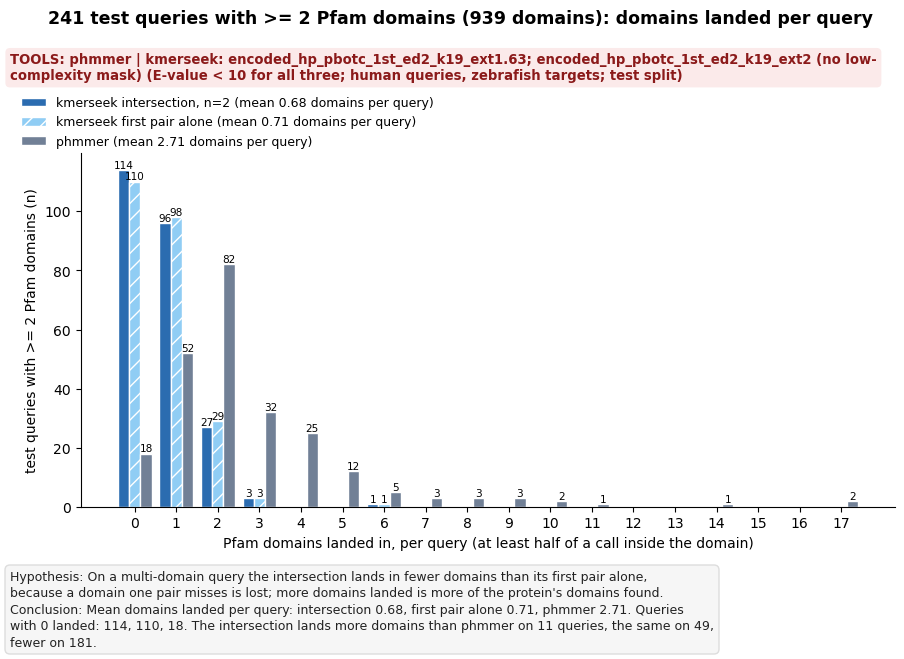

In [8]:
M_COLORS = {METHODS[0]: "#2B6CB0", METHODS[1]: "#90CDF4", "phmmer": "#718096"}
M_HATCH = {METHODS[0]: None, METHODS[1]: "//", "phmmer": None}
xs = np.arange(0, int(dist["n_landed"].max()) + 1)
fig, ax = plt.subplots(figsize=(9, 4.8))
w = 0.27
for i, m in enumerate(METHODS):
    d = dict(dist.filter(pl.col("method") == m).select("n_landed", "n_queries").iter_rows())
    ys = [d.get(int(x), 0) for x in xs]
    tool = "kmerseek " if m != "phmmer" else ""
    ax.bar(xs + (i - 1) * w, ys, width=w, color=M_COLORS[m], hatch=M_HATCH[m], edgecolor="white",
           label=f"{tool}{m} (mean {counts[m].mean():.2f} domains per query)")
    for x, y in zip(xs, ys):
        if y:
            ax.text(x + (i - 1) * w, y, str(y), ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(xs)
ax.set_xlabel("Pfam domains landed in, per query (at least half of a call inside the domain)")
ax.set_ylabel("test queries with >= 2 Pfam domains (n)")
ax.spines[["top", "right"]].set_visible(False)
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=1, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.89))
c = cmp.row(0, named=True)
mu.finish_figure(
    fig, FIG / "261_multidomain_domains_landed_intersection_vs_phmmer_zebrafish_test.png",
    tools=mu.tools_text(comparison=["hmmer3_phmmer"], kmerseek=PANEL, lc=False,
                        note=f"E-value < {EMAX:g} for all three; human queries, zebrafish targets; test split"),
    title=f"{multi.height} test queries with >= 2 Pfam domains ({multi['n_domains'].sum():_} domains): domains landed per query",
    hypothesis="On a multi-domain query the intersection lands in fewer domains than its "
               "first pair alone, because a domain one pair misses is lost; more domains "
               "landed is more of the protein's domains found.",
    conclusion=(f"Mean domains landed per query: intersection {counts[I].mean():.2f}, first pair alone "
                f"{counts[S].mean():.2f}, phmmer {counts['phmmer'].mean():.2f}. Queries with 0 landed: "
                f"{(counts[I] == 0).sum()}, {(counts[S] == 0).sum()}, {(counts['phmmer'] == 0).sum()}. "
                f"The intersection lands more domains than phmmer on {c['intersection_more_than_phmmer']} "
                f"queries, the same on {c['same']}, fewer on {c['phmmer_more']}."),
    layout=False,
)

# Summary and Conclusions

## Background

Combiner A calls a merged kmerseek region only when every alphabet-ksize pair in a fixed
panel calls it at `region_evalue` < E_max. This execution has four pairs, all
hp_pbotc_1st_ed2 at k=19 against zebrafish, and no shuffled-query run, so it tests the
code and the procedure, not agreement between alphabets. The numbers below are from this
execution and change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* On tune, the greedy search stops at two pairs at E_max 10, encoded hp_pbotc_1st_ed2
  k=19 at extension penalties 1.63 and 2, because no added pair raised Swiss-Prot
  precision above the single pair's 0.398.
* At every E_max, adding pairs lowered tune Swiss-Prot precision: 0.338 to 0.331 at
  E_max 0.1, 0.354 to 0.342 at 1, and 0.398 to 0.372 at 10, from one to four pairs.
* On test, the frozen two-pair intersection calls 720 merged regions against 747 for its
  first pair alone, with Swiss-Prot precision 0.341 against 0.346 and Pfam recall 0.291
  against 0.299.
* On 241 test queries with at least two Pfam domains, phmmer lands in a mean of 2.71
  domains per query, the intersection 0.68 and its first pair alone 0.71.
* The intersection lands in no Pfam domain on 114 of those 241 queries; phmmer on 18.
  It lands more domains than phmmer on 11 queries, the same on 49 and fewer on 181.
* No shuffled-query table exists, so this execution has no false-call count from
  shuffled queries for any panel.

## Analysis Details

The table is notebook 260's: kmerseek 0.4 calls with `region_evalue` < 10, merged across
pairs when two calls overlap by at least half the shorter one. A merged region is a true
call when at least half of it lies inside one truth feature. Precision counts only calls
on queries that have a feature in that truth set (741 of 780 tune calls for Swiss-Prot,
all 780 for Pfam). Recall counts truth features found once per target species searched.

Precision falls as pairs are added here, the opposite of what the intersection is for.
The four pairs are one search at two penalties, so a region one of them misses is not a
region the others disagree on for a biological reason. Notebook 260 found that regions
called by more pairs are longer, and a longer merged region lands less often inside one
feature.

The multi-domain comparison uses merged-region extents for kmerseek and single hits for
phmmer. A merged region that crosses a domain border lands in neither domain, which
counts against kmerseek here and not against phmmer. Swiss-Prot recall is bounded below
1 by one- and two-residue features (BINDING, SITE, ACT_SITE), which no region longer than
four residues can land in at half its length.

## Supplementary Information

- Input: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows; sha256 in `261_intersection_panel.yaml`), from notebook 260 on PR #88.
- Truth: `human_domain_truth.parquet` (Pfam) and `human_swissprot_truth.parquet`
  (Swiss-Prot) under the midi-plus run directory.
- phmmer: `regions/hmmer3_phmmer/human_vs_zebrafish.hmmer3_phmmer.tsv.gz`, midi-plus
  region benchmark (1-2 Sept 2026), i-Evalue per domain.
- Code: `notebooks/region_combiner_261.py`, `notebooks/261_build_notebook.py`.
- To rebuild on the full run: run `make run-midi-plus-0.4-extend` and the
  `M04_RUN=decoy` twin, reduce both with notebook 260's code, write
  `region_table_decoy.parquet` beside the real table, then re-execute this notebook.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb): the region table this notebook reads.
- Eddy, S. R. "Accelerated Profile HMM Searches." *PLoS Computational Biology* 7, no. 10
  (2011): e1002195. DOI still needs checking.

In [9]:
summary_md = r"""
# Summary and Conclusions

## Background

Combiner A calls a merged kmerseek region only when every alphabet-ksize pair in a fixed
panel calls it at `region_evalue` < E_max. This execution has four pairs, all
hp_pbotc_1st_ed2 at k=19 against zebrafish, and no shuffled-query run, so it tests the
code and the procedure, not agreement between alphabets. The numbers below are from this
execution and change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* On tune, the greedy search stops at two pairs at E_max 10, encoded hp_pbotc_1st_ed2
  k=19 at extension penalties 1.63 and 2, because no added pair raised Swiss-Prot
  precision above the single pair's 0.398.
* At every E_max, adding pairs lowered tune Swiss-Prot precision: 0.338 to 0.331 at
  E_max 0.1, 0.354 to 0.342 at 1, and 0.398 to 0.372 at 10, from one to four pairs.
* On test, the frozen two-pair intersection calls 720 merged regions against 747 for its
  first pair alone, with Swiss-Prot precision 0.341 against 0.346 and Pfam recall 0.291
  against 0.299.
* On 241 test queries with at least two Pfam domains, phmmer lands in a mean of 2.71
  domains per query, the intersection 0.68 and its first pair alone 0.71.
* The intersection lands in no Pfam domain on 114 of those 241 queries; phmmer on 18.
  It lands more domains than phmmer on 11 queries, the same on 49 and fewer on 181.
* No shuffled-query table exists, so this execution has no false-call count from
  shuffled queries for any panel.

## Analysis Details

The table is notebook 260's: kmerseek 0.4 calls with `region_evalue` < 10, merged across
pairs when two calls overlap by at least half the shorter one. A merged region is a true
call when at least half of it lies inside one truth feature. Precision counts only calls
on queries that have a feature in that truth set (741 of 780 tune calls for Swiss-Prot,
all 780 for Pfam). Recall counts truth features found once per target species searched.

Precision falls as pairs are added here, the opposite of what the intersection is for.
The four pairs are one search at two penalties, so a region one of them misses is not a
region the others disagree on for a biological reason. Notebook 260 found that regions
called by more pairs are longer, and a longer merged region lands less often inside one
feature.

The multi-domain comparison uses merged-region extents for kmerseek and single hits for
phmmer. A merged region that crosses a domain border lands in neither domain, which
counts against kmerseek here and not against phmmer. Swiss-Prot recall is bounded below
1 by one- and two-residue features (BINDING, SITE, ACT_SITE), which no region longer than
four residues can land in at half its length.

## Supplementary Information

- Input: `~/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet`
  (6_140 rows; sha256 in `261_intersection_panel.yaml`), from notebook 260 on PR #88.
- Truth: `human_domain_truth.parquet` (Pfam) and `human_swissprot_truth.parquet`
  (Swiss-Prot) under the midi-plus run directory.
- phmmer: `regions/hmmer3_phmmer/human_vs_zebrafish.hmmer3_phmmer.tsv.gz`, midi-plus
  region benchmark (1-2 Sept 2026), i-Evalue per domain.
- Code: `notebooks/region_combiner_261.py`, `notebooks/261_build_notebook.py`.
- To rebuild on the full run: run `make run-midi-plus-0.4-extend` and the
  `M04_RUN=decoy` twin, reduce both with notebook 260's code, write
  `region_table_decoy.parquet` beside the real table, then re-execute this notebook.

## References

- [Notebook 260](260_kmerseek_region_table.ipynb): the region table this notebook reads.
- Eddy, S. R. "Accelerated Profile HMM Searches." *PLoS Computational Biology* 7, no. 10
  (2011): e1002195. DOI still needs checking.
"""
print(summary_md)


# Summary and Conclusions

## Background

Combiner A calls a merged kmerseek region only when every alphabet-ksize pair in a fixed
panel calls it at `region_evalue` < E_max. This execution has four pairs, all
hp_pbotc_1st_ed2 at k=19 against zebrafish, and no shuffled-query run, so it tests the
code and the procedure, not agreement between alphabets. The numbers below are from this
execution and change when notebook 260 is rebuilt on the full run.

## Summary and Conclusions

* On tune, the greedy search stops at two pairs at E_max 10, encoded hp_pbotc_1st_ed2
  k=19 at extension penalties 1.63 and 2, because no added pair raised Swiss-Prot
  precision above the single pair's 0.398.
* At every E_max, adding pairs lowered tune Swiss-Prot precision: 0.338 to 0.331 at
  E_max 0.1, 0.354 to 0.342 at 1, and 0.398 to 0.372 at 10, from one to four pairs.
* On test, the frozen two-pair intersection calls 720 merged regions against 747 for its
  first pair alone, with Swiss-Prot precision 0.34